In [23]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from thefuzz import process,fuzz

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

plt.style.use('dark_background')

cyber_palette = ['#ff00ff','#00ffff','#39ff14','#ff1493','#9400d3']
sns.set_palette(cyber_palette)

plt.rcParams['figure.figsize']=(8,5)
plt.rcParams['axes.facecolor']='#0d0d0d'
plt.rcParams['grid.color']='#444444'
plt.rcParams['axes.edgecolor']='#ffffff'

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw")


ROOT = find_project_root(Path.cwd().resolve())
DATA_DIR = ROOT / "data" / "raw"
DATA_ext = ROOT / "data" / "external"
print(f"Project root: {ROOT}")
print(f"Data dir: {DATA_DIR}")
print(f"Data ext: {DATA_ext}")

Project root: C:\Users\gshar\anime-recommendation
Data dir: C:\Users\gshar\anime-recommendation\data\raw
Data ext: C:\Users\gshar\anime-recommendation\data\external


In [24]:
# Kaggle data
anime  = pd.read_csv(DATA_ext / "anime.csv")
rating = pd.read_csv(DATA_ext / "rating.csv")
fandom = pd.read_csv(DATA_DIR / "fandom.csv")


In [34]:
def quality_report(frame: pd.DataFrame, name: str) -> pd.DataFrame:
    report = pd.DataFrame(
        {
            "dtype": frame.dtypes.astype(str),
            "nulls": frame.isna().sum(),
            "null_pct": (frame.isna().mean() * 100).round(2),
            "nunique": frame.nunique(dropna=False),
        }
    ).sort_values(["null_pct", "nunique"], ascending=[False, True]).style.background_gradient(cmap='cool')
    print(f"{name} shape: {frame.shape}")
    print(f"{name} duplicate rows: {frame.duplicated().sum()}")
    print(f"{name} mathematical view:\n ")
    display(frame.describe().T.style.background_gradient(cmap='cool'))
    print('--'*50)
    print('DATA INFO')
    print('--'*50)
    return report


display(quality_report(anime, "anime"))
display(quality_report(rating, "rating"))
display(quality_report(fandom, "fandom"))

print("duplicate anime_ids:", anime["anime_id"].duplicated().sum())
print("duplicate user_ids:", rating["user_id"].duplicated().sum())
print("duplicate page_ids:", fandom["pageid"].duplicated().sum())


anime shape: (12294, 7)
anime duplicate rows: 0
anime mathematical view:
 


,count,mean,std,min,25%,50%,75%,max
anime_id,12294.000000,14058.221653,11455.294701,1.000000,3484.250000,10260.500000,24794.500000,34527.000000
rating,12064.000000,6.473902,1.026746,1.670000,5.880000,6.570000,7.180000,10.000000
members,12294.000000,18071.338864,54820.676925,5.000000,225.000000,1550.000000,9437.000000,1013917.000000


----------------------------------------------------------------------------------------------------
DATA INFO
----------------------------------------------------------------------------------------------------


,dtype,nulls,null_pct,nunique
rating,float64,230,1.870000,599
genre,str,62,0.500000,3265
type,str,25,0.200000,7
episodes,str,0,0.000000,187
members,int64,0,0.000000,6706
name,str,0,0.000000,12292
anime_id,int64,0,0.000000,12294


rating shape: (7813737, 3)
rating duplicate rows: 1
rating mathematical view:
 


...

fandom shape: (10014, 3)
fandom duplicate rows: 0
fandom mathematical view:
 


,count,mean,std,min,25%,50%,75%,max
pageid,10014.000000,19577.639704,8760.857005,1461.000000,12464.250000,20243.000000,27982.750000,31691.000000


----------------------------------------------------------------------------------------------------
DATA INFO
----------------------------------------------------------------------------------------------------


,dtype,nulls,null_pct,nunique
description,str,0,0.000000,8505
pageid,int64,0,0.000000,10014
title,str,0,0.000000,10014


duplicate anime_ids: 0
duplicate user_ids: 7740222
duplicate page_ids: 0


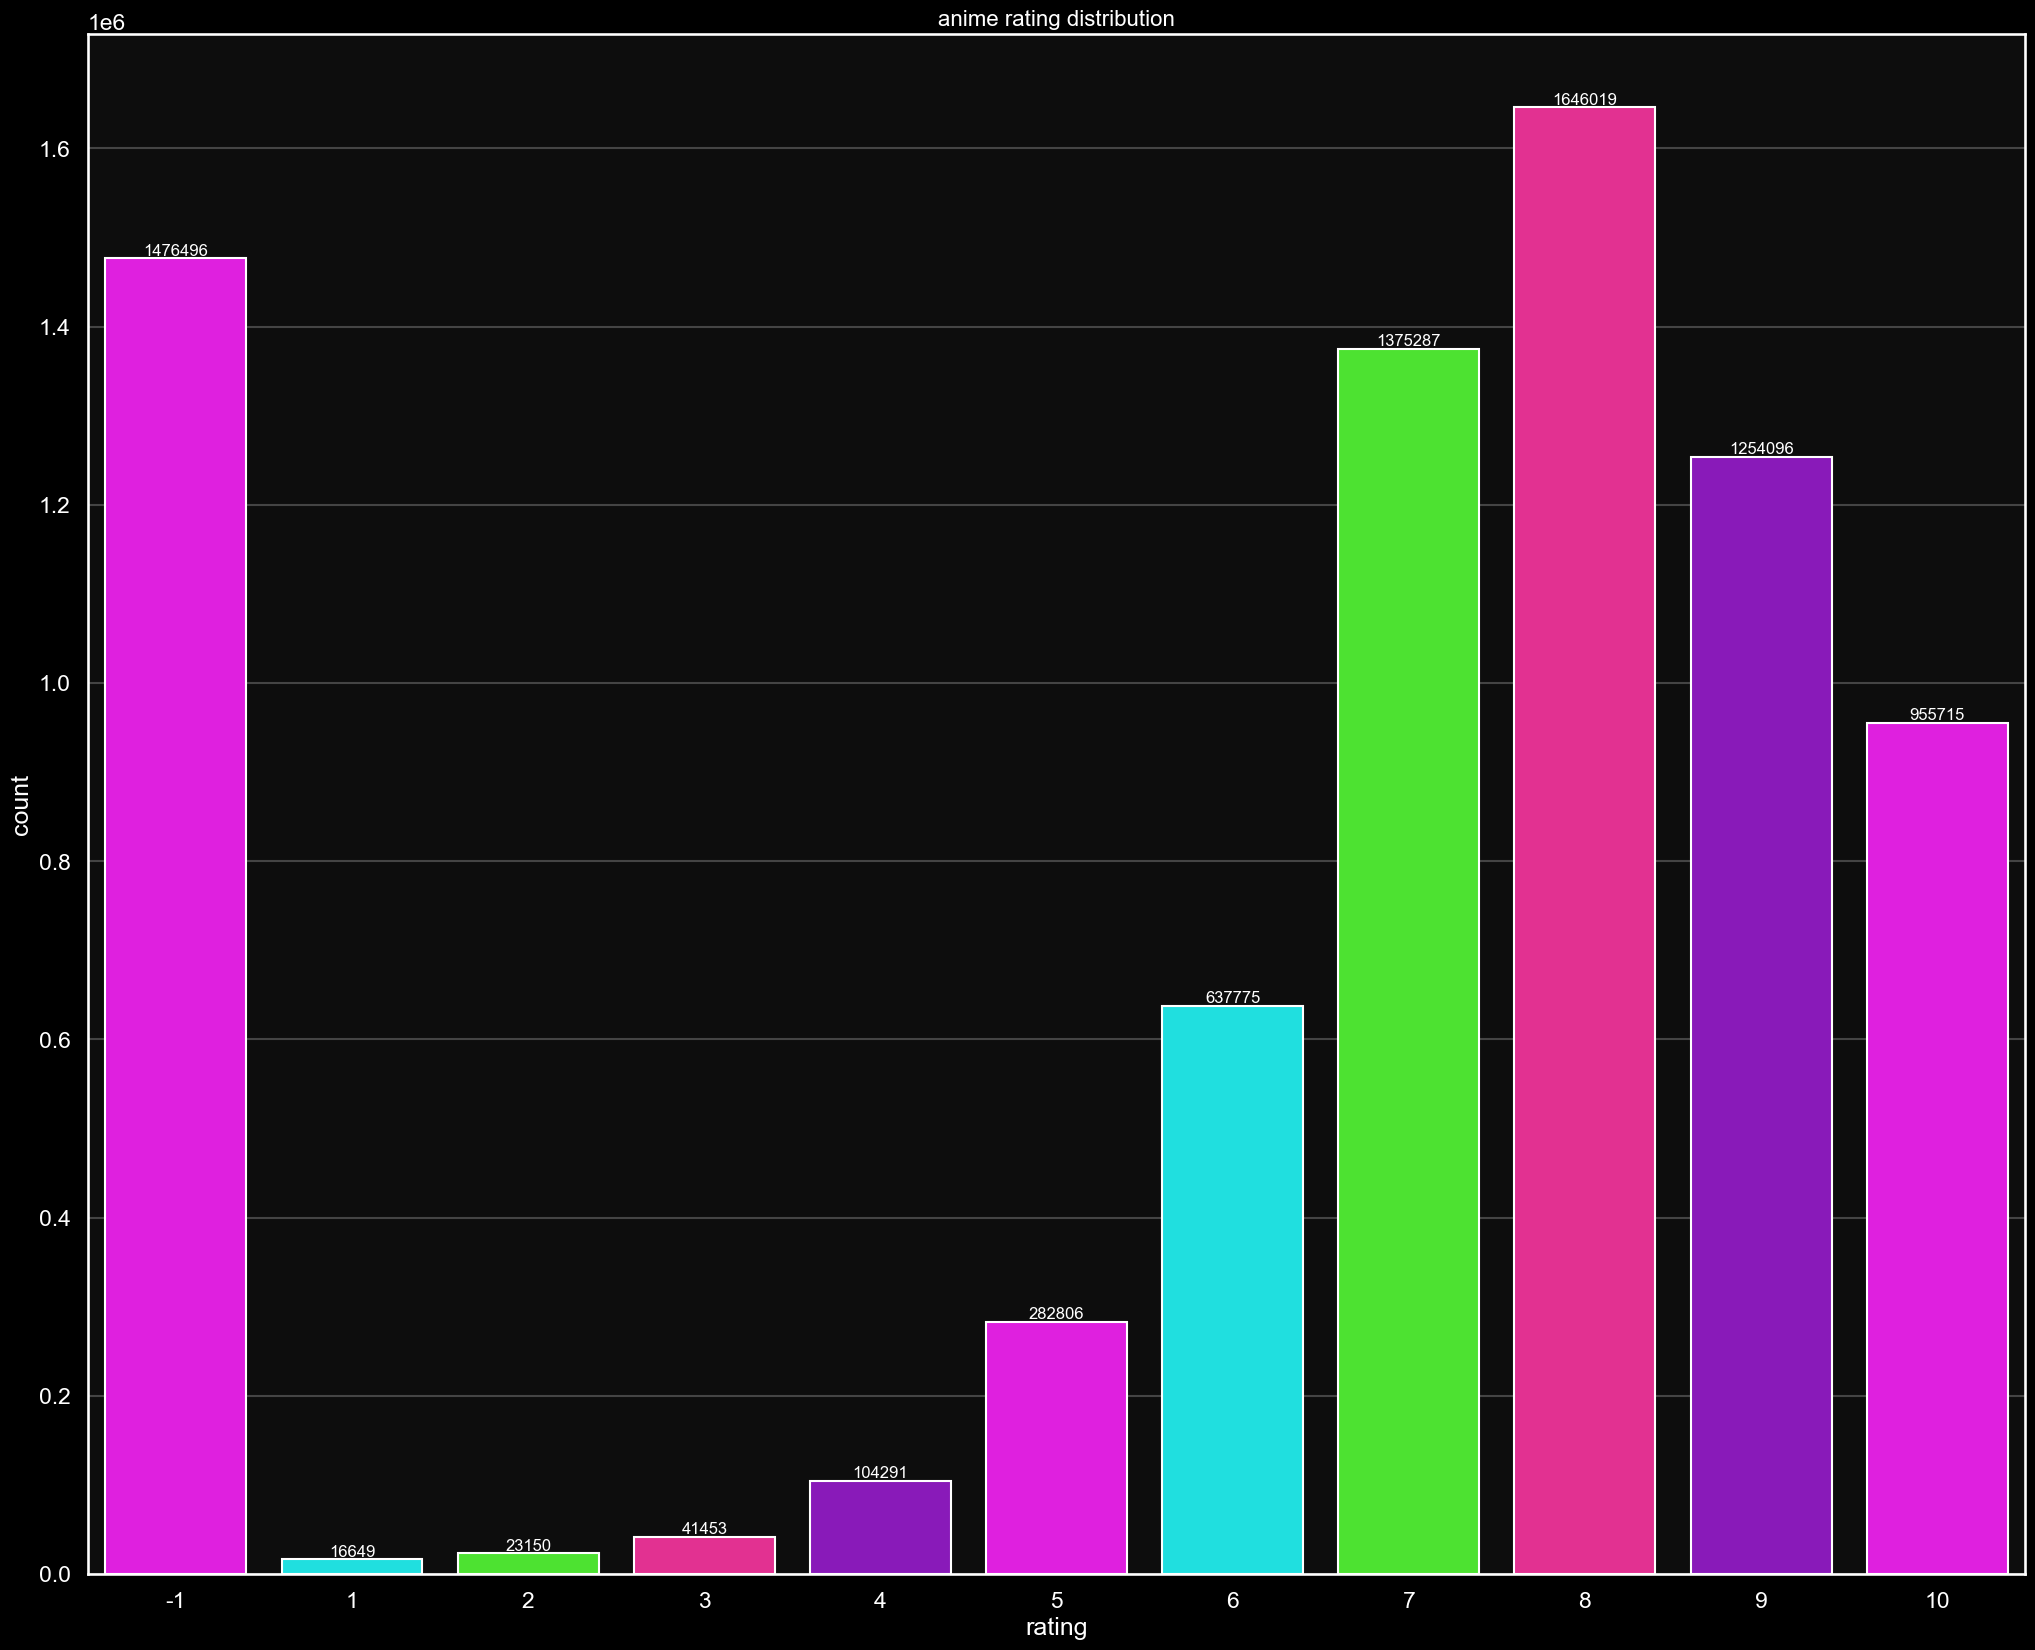

In [69]:

plt.figure(figsize=(25,20))

ax = sns.countplot(
    x='rating',
    data=rating,
    palette=cyber_palette
)

# Add value counts on bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',   # value count
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=12
    )

plt.title('anime rating distribution', fontsize=16)
plt.show()

In [70]:
rating.groupby('user_id').size().describe() 

count    73515.000000
mean       106.287656
std        153.086558
min          1.000000
25%         18.000000
50%         57.000000
75%        136.000000
max      10227.000000
dtype: float64

In [71]:
fandom['description'].str.len().describe()

count    10014.000000
mean       328.301578
std        222.067027
min         15.000000
25%         40.000000
50%        500.000000
75%        500.000000
max        500.000000
Name: description, dtype: float64

<Axes: >

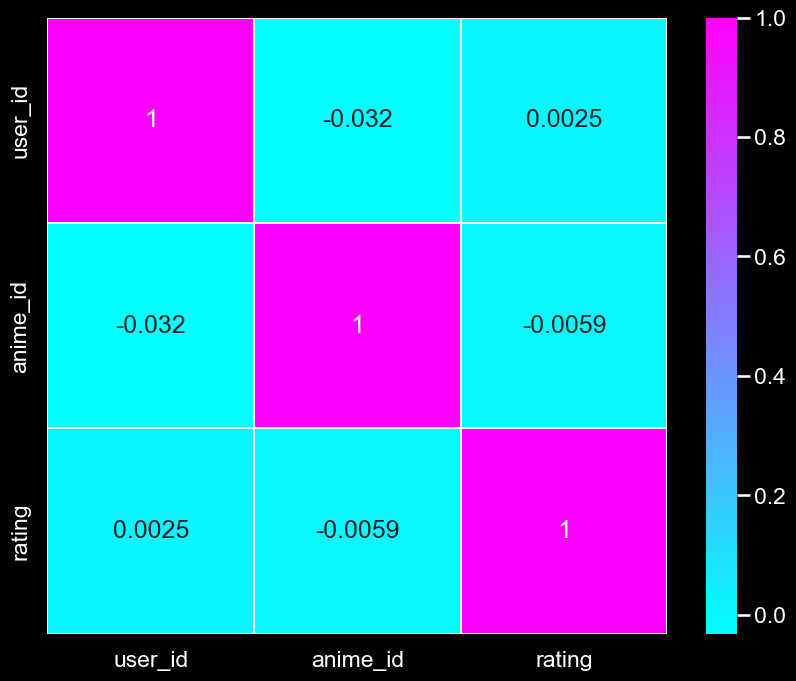

In [72]:
plt.figure(figsize=(10,8))
corr = rating.corr(numeric_only=True)

sns.heatmap(corr,annot = True,cmap='cool',linewidths=0.3)

<Axes: >

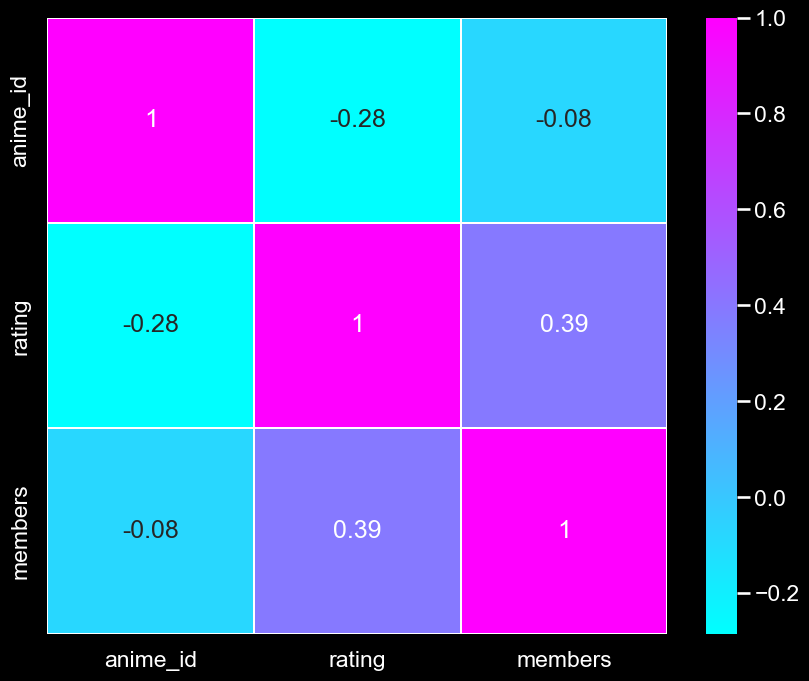

In [73]:
plt.figure(figsize=(10,8))
corr = anime.corr(numeric_only=True)

sns.heatmap(corr,annot = True,cmap='cool',linewidths=0.3)

Text(0.5, 1.0, 'anime ratings')

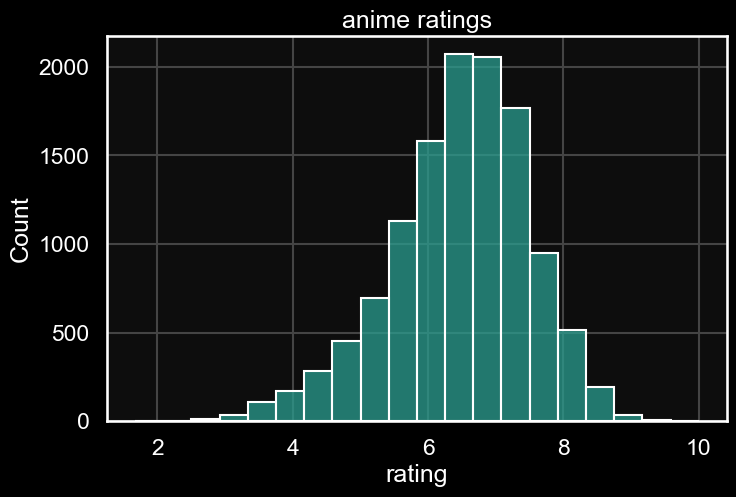

In [74]:
sns.histplot(anime["rating"], bins=20,  color="#2a9d8f")
plt.title("anime ratings")

In [ ]:
fandom_lookup = dict(zip(fandom['title'], fandom['description']))
fandom_titles = list(fandom_lookup.keys())
def find_best_match(title, fandom_titles, threshold=80):
    result = process.extractOne(title, fandom_titles, scorer=fuzz.token_sort_ratio)
    if result is None:
        return None
    match_title, score = result
    return match_title if score >= threshold else None

anime['match_key'] = anime['name'].apply(
    lambda x: find_best_match(x, fandom_titles)
)

# merged_anime = pd.merge(anime, fandom, left_on='match_key', right_on='title', how='left')